# Projeto Matching de Hoteis - Gabriel Ferreira

In [1]:
#imports
import pandas as pd
import numpy as np
import re
from Levenshtein import ratio as levenshtein_ratio
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

In [2]:
hotels_A = pd.read_csv('hotels_A.csv')
hotels_B = pd.read_csv('hotels_B.csv')
train_truth_df = pd.read_csv('train.csv')

## EDA - Análise Exploratória de Dados

In [3]:
hotels_A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_A           436 non-null    object 
 1   hotel_name     436 non-null    object 
 2   address        436 non-null    object 
 3   city           436 non-null    object 
 4   country        436 non-null    object 
 5   latitude       436 non-null    float64
 6   longitude      436 non-null    float64
 7   rating         436 non-null    float64
 8   reviews_count  436 non-null    int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 30.8+ KB


In [4]:
hotels_B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id_B           425 non-null    object 
 1   hotel_name     425 non-null    object 
 2   address        425 non-null    object 
 3   city           425 non-null    object 
 4   country        425 non-null    object 
 5   latitude       425 non-null    float64
 6   longitude      425 non-null    float64
 7   rating         425 non-null    float64
 8   reviews_count  425 non-null    int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 30.0+ KB


In [5]:
print(hotels_A.count())
print(hotels_B.count())

id_A             436
hotel_name       436
address          436
city             436
country          436
latitude         436
longitude        436
rating           436
reviews_count    436
dtype: int64
id_B             425
hotel_name       425
address          425
city             425
country          425
latitude         425
longitude        425
rating           425
reviews_count    425
dtype: int64


In [6]:
hotels_A.isnull().sum()

id_A             0
hotel_name       0
address          0
city             0
country          0
latitude         0
longitude        0
rating           0
reviews_count    0
dtype: int64

In [7]:
hotels_B.isnull().sum()

id_B             0
hotel_name       0
address          0
city             0
country          0
latitude         0
longitude        0
rating           0
reviews_count    0
dtype: int64

In [8]:
# Verificação de Duplicadas
num_duplicatas_hotels_A = hotels_A.duplicated().sum()
print(num_duplicatas_hotels_A)

num_duplicatas_hotels_B = hotels_B.duplicated().sum()
print(num_duplicatas_hotels_B)

0
0


In [9]:
# Amostra hotels_A
hotels_A.sample(10)

,id_A,hotel_name,address,city,country,latitude,longitude,rating,reviews_count
105,A00105,Residency Gaudí Saint,"Avenue Europa, 2157",Madrid,ES,40.508980,-3.682180,4.1,565
322,A00322,Hotel Liberdade Saint,"Avenue Paulista, 817",Rio de Janeiro,BR,-22.912305,-43.208764,4.9,689
39,A00039,Residency Cathedral II,"Avenida da Sé, 9556",Porto Alegre,BR,-30.061022,-51.203027,4.0,72
234,A00234,Inn Cathedral Saint,"Street das Flores, 1975",Barcelona,ES,41.386193,2.179595,4.7,451
280,A00280,Inn Augusta II,"Ave Liberdade, 9011",Lisboa,PT,38.710336,-9.102480,3.9,1105
99,A00099,Pousada Paulista,"Praça da Sé, 5053",Porto,PT,41.205343,-8.587115,3.3,709
21,A00021,Palace Cathedral II,"Avenue Central, 8498",Curitiba,BR,-25.475413,-49.315451,3.6,219
269,A00269,Suites Cathedral Boutique,"Rua das Flores, 7685",Porto,PT,41.182048,-8.630130,4.5,499
107,A00107,Residency Cathedral,"Street Augusta, 1325",Rio de Janeiro,BR,-22.943759,-43.181441,4.3,927
230,A00230,Hotel Central,"Street dos Andradas, 1284",Curitiba,BR,-25.415942,-49.338261,4.7,915


In [10]:
# Amostra hotels_B
hotels_B.sample(10)

,id_B,hotel_name,address,city,country,latitude,longitude,rating,reviews_count
398,B00398,Grand Augusta,"Av. dos Andradas, 6749",Porto,PT,41.029534,-8.688313,4.3,504
351,B00351,Seine,"Praça da República, 2673",Belo Horizonte,BR,-19.892253,-43.930696,4.2,891
407,B00407,Pousada Cathedral,"Avenue Copacabana, 1182",Porto Alegre,BR,-30.088416,-51.217378,5.0,74
190,B00190,Pousada Seine,"Avenue Central, 1101",Madrid,ES,40.435777,-3.699909,4.6,311
340,B00340,Suites Central,"Rua dos Andradas, 2295",Porto,PT,41.212133,-8.634242,3.8,403
155,B00155,Pousada Seine Saint,"Avenida das Flores, 1592",Porto,PT,41.069444,-8.586601,4.1,698
95,B00095,Suites Cathedral II & Spa,"Avenida Central, 1192",Barcelona,ES,41.419385,2.214811,4.7,321
219,B00219,Central,"Street dos Andradas, 1284",Curitiba,BR,-25.414338,-49.339077,4.3,1045
309,B00309,Suites Paulista II,Praça Europa 7082,Porto Alegre,BR,-30.066019,-51.240950,4.0,90
392,B00392,Pousada Augusta II,Pça. Central 8948,Porto,PT,41.071023,-8.650831,4.0,452


Iremos utilizar uma abordagem com Distância de Levenshtein para calcular a similaridade de strings e a Distância de Haversine para calcular a distância entre os hoteis, assim consiguimos reduzir o número de comparações a serem realizadas e otimzamos recurso computacional.

Inicalmente precisamos normalizar os dados e em seguida aplicar as transformações necessárias. Realizamos o trabalho de limpeza e normalização das features que possuem strings, para isso iremos converter as strings para letras minúsculas, remover todas as pontuações e espaços extras e após uma análise remover os termos mais comuns que não necessariamente agregariam valor para comparação e sim seriam uma especie de "rúido" nos dados

## Pré Processamento

Antes de analisar os termos mais comuns vamos verificar a consistência das duas basesm verificando se as cidades e os países estão padronizados e sem erros

In [11]:
paises_hotelsA = hotels_A['country'].unique()
print(f"Países hotels_A:")
print(paises_hotelsA)
print()
cidades_hotelsA = hotels_A['city'].unique()
print(f"Cidades em hotels_A:")
print(cidades_hotelsA)
print()
print()
paises_hotelsB = hotels_B['country'].unique()
print(f"Países hotels_B:")
print(paises_hotelsB)
print()
cidades_hotelsB = hotels_A['city'].unique()
print(f"Cidades em hotels_B:")
print(cidades_hotelsB)

Países hotels_A:
['PT' 'FR' 'ES' 'BR']

Cidades em hotels_A:
['Porto' 'Paris' 'Lisboa' 'Barcelona' 'Curitiba' 'Porto Alegre'
 'São Paulo' 'Rio de Janeiro' 'Belo Horizonte' 'Madrid']


Países hotels_B:
['ES' 'PT' 'BR' 'FR']

Cidades em hotels_B:
['Porto' 'Paris' 'Lisboa' 'Barcelona' 'Curitiba' 'Porto Alegre'
 'São Paulo' 'Rio de Janeiro' 'Belo Horizonte' 'Madrid']


In [12]:
# Identificação e Seleção de Termos Genéricos para Remoção
all_names_addresses = pd.concat([
    hotels_A['hotel_name'].astype(str),
    hotels_A['address'].astype(str),
    hotels_B['hotel_name'].astype(str),
    hotels_B['address'].astype(str)
])
def basic_clean_for_word_count(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
cleaned_all_texts_for_count = all_names_addresses.apply(basic_clean_for_word_count)
from collections import Counter
all_words = ' '.join(cleaned_all_texts_for_count).split()
word_counts = Counter(all_words)
most_common_words = word_counts.most_common(50)
for word, count in most_common_words:
    print(f"'{word}': {count}")

'hotel': 211
'ii': 194
'augusta': 193
'saint': 191
'da': 180
'liberdade': 177
'central': 170
'avenue': 167
'praça': 162
'rua': 161
'copacabana': 156
'avenida': 153
'europa': 152
'paulista': 145
'inn': 136
'street': 136
'pousada': 128
'grand': 121
'residency': 121
'palace': 119
'suites': 110
'gaudí': 106
'dos': 99
'andradas': 99
'cathedral': 97
'sé': 91
'das': 89
'flores': 89
'república': 89
'seine': 85
'lumière': 73
'spa': 61
'boutique': 56
'st': 26
'pça': 23
'ave': 18
'r': 17
'av': 12
'2': 9
'7575': 4
'1532': 4
'4531': 4
'4671': 4
'7070': 4
'146': 4
'9078': 4
'5627': 4
'1284': 4
'6749': 4
'2556': 4


Após análise optamos por remover os seguintes termos pois não agregam valor distintivo:
* 'da', 'dos', 'das' que são Artigos e Preposições,
* 'hotel', 'inn', 'pousada', 'grand', 'residency', 'palace', 'suites', 'boutique', que são  os tipos de Estabelecimento
* 'avenue', 'av', 'street', 'r', 'rua', 'praça', 'pça', 'avenida', 'ave' que são os Tipos de Logradouro
* 'ii', 'i', '2', 'st' que são Numerais/Abreviações Ambíguas/Genéricas

In [13]:
# Lista com os termos comuns
common_terms_to_remove = [
    'da', 'dos', 'das',
    'hotel', 'inn', 'pousada', 'grand', 'residency', 'palace', 'suites', 'boutique', 'spa', 'saint',
    'avenue', 'av', 'street', 'r', 'rua', 'praça', 'pça', 'avenida', 'ave',
    'ii', 'i', '2', 'st'
]
common_terms_to_remove_set = set([term.lower() for term in common_terms_to_remove])

In [14]:
# Função de Limpeza de Texto
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    
    # 1. Remove pontuações e normaliza espaços, mantendo caracteres acentuados comuns
    text = re.sub(r'[^\w\sÀ-ÿ]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 2. Remove termos comuns usando o set GLOBAL
    words = text.split()
    filtered_words = [word for word in words if word not in common_terms_to_remove_set]
    text = " ".join(filtered_words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [15]:
# Aplicando as funções de limpeza e a criação das novas colunas
for df in [hotels_A, hotels_B]:
    df['cleaned_hotel_name'] = df['hotel_name'].apply(clean_text)
    df['cleaned_address'] = df['address'].apply(clean_text)
    df['cleaned_city'] = df['city'].apply(clean_text)
    df['cleaned_country'] = df['country'].apply(clean_text)

In [16]:
# 5 primeiras linhas do df1
hotels_A.head()

,id_A,hotel_name,address,city,country,latitude,longitude,rating,reviews_count,cleaned_hotel_name,cleaned_address,cleaned_city,cleaned_country
0,A00000,Inn Europa Saint,"Street Paulista, 1106",Porto,PT,41.115784,-8.640587,3.4,412,europa,paulista 1106,porto,pt
1,A00001,Hotel Cathedral II,"Avenue Augusta, 2592",Paris,FR,48.791519,2.423506,3.7,287,cathedral,augusta 2592,paris,fr
2,A00002,Pousada Seine II,"Avenue Copacabana, 4269",Porto,PT,41.117182,-8.610908,5.0,690,seine,copacabana 4269,porto,pt
3,A00003,Palace Copacabana Saint,"Av. das Flores, 6372",Lisboa,PT,38.795851,-9.041365,3.1,61,copacabana,flores 6372,lisboa,pt
4,A00004,Augusta,"Rua Copacabana, 2477",Porto,PT,41.161633,-8.564832,3.9,893,augusta,copacabana 2477,porto,pt


In [17]:
# 5 primeiras linhas do df2
hotels_B.head()

,id_B,hotel_name,address,city,country,latitude,longitude,rating,reviews_count,cleaned_hotel_name,cleaned_address,cleaned_city,cleaned_country
0,B00000,Palace Augusta,"Pça. Central, 7844",Barcelona,ES,41.336272,2.134553,3.7,399,augusta,central 7844,barcelona,es
1,B00001,Pousada Paulista,"Avenue das Flores, 1830",Madrid,ES,40.358635,-3.730172,4.0,603,paulista,flores 1830,madrid,es
2,B00002,Inn Gaudí Boutique,Avenue das Flores 8677,Porto,PT,41.127530,-8.543111,4.1,798,gaudí,flores 8677,porto,pt
3,B00003,Suites Europa,"Street Liberdade, 7617",Porto,PT,41.170730,-8.505382,3.2,710,europa,liberdade 7617,porto,pt
4,B00004,Residency Paulista,Avenue Copacabana 9880,Curitiba,BR,-25.382215,-49.385295,4.3,896,paulista,copacabana 9880,curitiba,br


Por conta de termos 436 hoteis no df1 e 425 no df2, teriamos 436 * 425 = 185.300 pares para comparar individualmente, para reduzir o numero de comparações iremos primeiramente fazer uma primeira filtragem com a maior probabilidade de ser o mesmo hotel utilizando cidade e pais, ou seja vamos criar pares que estão na mesma cidade e país.

In [18]:
# Implementando a Estratégia de Blocking (Filtro) por cidade e país

# 1. Criar uma chave de bloqueio combinando cidade e país para ambas as bases
hotels_A['block_key'] = hotels_A['cleaned_city'] + '_' + hotels_A['cleaned_country']
hotels_B['block_key'] = hotels_B['cleaned_city'] + '_' + hotels_B['cleaned_country']

# 2. Agrupar os hotéis de hotels_B por suas chaves de bloqueio
blocks_B = hotels_B.groupby('block_key')

# 3. Gerar pares potenciais de matching
potential_matches_list = []
total_comparisons = 0

common_block_keys = set(hotels_A['block_key'].unique()).intersection(set(hotels_B['block_key'].unique()))
for block_key in common_block_keys:
    block_A = hotels_A[hotels_A['block_key'] == block_key]
    block_B = blocks_B.get_group(block_key)
    for _, row_a in block_A.iterrows():
        for _, row_b in block_B.iterrows():
            potential_matches_list.append({
                'id_A': row_a['id_A'],
                'id_B': row_b['id_B'],
                'hotel_name_A': row_a['hotel_name'],
                'cleaned_hotel_name_A': row_a['cleaned_hotel_name'],
                'address_A': row_a['address'],
                'cleaned_address_A': row_a['cleaned_address'],
                'city_A': row_a['city'],
                'country_A': row_a['country'],
                'latitude_A': row_a['latitude'],
                'longitude_A': row_a['longitude'],
                'hotel_name_B': row_b['hotel_name'],
                'cleaned_hotel_name_B': row_b['cleaned_hotel_name'],
                'address_B': row_b['address'],
                'cleaned_address_B': row_b['cleaned_address'],
                'city_B': row_b['city'],
                'country_B': row_b['country'],
                'latitude_B': row_b['latitude'],
                'longitude_B': row_b['longitude']
            })
            total_comparisons += 1

potential_matches_df = pd.DataFrame(potential_matches_list)
print(f"Tamanho do DataFrame de potenciais pares: {len(potential_matches_df)} linhas.")

Tamanho do DataFrame de potenciais pares: 18890 linhas.


A estratégia incial de Blocking (Filtro) reduziu o número de pares a serem comparados de 185.300 para 18.890. Isso é uma redução de quase 90% no número de comparações, demonstrando a eficácia e a necessidade do blocking.

Antes de realizarmos a comparação efetivamente iremos comparar hoteis proximos apenas, pois temos latitude e longitude

A ideia de adicionar um blocking geográfico (ou um filtro de pré-similaridade baseado em raio) após o blocking por cidade/país e antes de calcular todas as similaridades de strings é uma tática potencialemnte eficaz por conta de:

* Otimização de Performance: Calcular a haversine_distance é computacionalmente mais barato do que calcular levenshtein_ratio para strings longas. Ao filtrar os pares que já estão muito distantes geograficamente (mesmo estando na mesma cidade/país) antes de aplicar os cálculos de string, você reduz drasticamente o número de chamadas para Levenshtein, que é a operação mais cara aqui.
* Aumento da Precisão: Se dois hotéis estão na mesma cidade/país, mas a quilômetros de distância um do outro, a chance de serem o mesmo hotel é extremamente baixa.

In [19]:
# Função do Cálculo da Distância de Haversine
def haversine_distance(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return float('inf')

    R = 6371

    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c
    return distance

In [20]:
# Implementando o segundo filtro por distância entre os hoteis
# 1. Calcular a distância Haversine para todos os pares potenciais
potential_matches_df['geo_distance_km'] = potential_matches_df.apply(
    lambda row: haversine_distance(
        row['latitude_A'], row['longitude_A'],
        row['latitude_B'], row['longitude_B']
    ), axis=1
)
# 2. Definir o raio máximo para o blocking geográfico
MAX_GEO_BLOCKING_DISTANCE_KM = 1.0
# 3. Filtrar o DataFrame para criar o geo_blocked_df
geo_blocked_df = potential_matches_df[
    potential_matches_df['geo_distance_km'] <= MAX_GEO_BLOCKING_DISTANCE_KM
].copy()

#4 Calculando similaridades de nome e endereço para os pares
geo_blocked_df['name_similarity'] = geo_blocked_df.apply(
    lambda row: levenshtein_ratio(row['cleaned_hotel_name_A'], row['cleaned_hotel_name_B']), axis=1
)
geo_blocked_df['address_similarity'] = geo_blocked_df.apply(
    lambda row: levenshtein_ratio(row['cleaned_address_A'], row['cleaned_address_B']), axis=1
)

In [21]:
# 5 primeiras linhas do df após as distancias calculadas
geo_blocked_df.head()

,id_A,id_B,hotel_name_A,cleaned_hotel_name_A,address_A,cleaned_address_A,city_A,country_A,latitude_A,longitude_A,...,cleaned_hotel_name_B,address_B,cleaned_address_B,city_B,country_B,latitude_B,longitude_B,geo_distance_km,name_similarity,address_similarity
267,A00037,B00008,Grand Lumière,lumière,"Avenida Augusta, 3074",augusta 3074,Curitiba,BR,-25.420240,-49.226302,...,liberdade,"Avenue Liberdade, 3447",liberdade 3447,Curitiba,BR,-25.418427,-49.229646,0.391700,0.500000,0.307692
350,A00038,B00238,Hotel Augusta II,augusta,"Avenue Paulista, 6590",paulista 6590,Curitiba,BR,-25.414031,-49.308355,...,cathedral,"Praça Augusta, 1532",augusta 1532,Curitiba,BR,-25.412062,-49.302287,0.647577,0.375000,0.560000
370,A00038,B00418,Hotel Augusta II,augusta,"Avenue Paulista, 6590",paulista 6590,Curitiba,BR,-25.414031,-49.308355,...,liberdade,"Pça. das Flores, 1168",flores 1168,Curitiba,BR,-25.422225,-49.309325,0.916324,0.125000,0.333333
478,A00077,B00005,Palace Copacabana,copacabana,"Street da República, 6236",república 6236,Curitiba,BR,-25.373371,-49.249763,...,seine,Avenue dos Andradas 6285,andradas 6285,Curitiba,BR,-25.365414,-49.246590,0.940459,0.133333,0.370370
488,A00077,B00066,Palace Copacabana,copacabana,"Street da República, 6236",república 6236,Curitiba,BR,-25.373371,-49.249763,...,copacabana,"Street da República, 6236",república 6236,Curitiba,BR,-25.372783,-49.251889,0.223379,1.000000,1.000000


## Criação do Algorítimo de Matching

Após as duas filtragens iniciais, vamos realizar um estudo de otimização dos parâmetros utilizados (similaridade do nome do hotel, do endereço do hotel e a distância dos hoteis) com base na ultima filtragem. Iremos testar diferentes valores e criaremos métricas e gráficos para definição dos melhores valores. Como temos train.csv podemos testar e definir os melhores valores para maximização do F1-Score

In [22]:
# Dividimos train_truth_df em train_split (80% para tuning) e val_split (20% para validação unseen)
train_split, val_split = train_test_split(
    train_truth_df, 
    test_size=0.2,
    stratify=train_truth_df['is_match'],
    random_state=42
)

print("=== SPLIT 80/20 REALIZADO ===")
print(f"Train original: {len(train_truth_df)} pares (matches: {train_truth_df['is_match'].sum()})")
print(f"Train split (80%): {len(train_split)} pares (matches: {train_split['is_match'].sum()})")
print(f"Val split (20%): {len(val_split)} pares (matches: {val_split['is_match'].sum()})")
print("Proporção de matches mantida (~50%) em ambos.")
print("Agora, usaremos train_split para tuning thresholds e val_split para F1 final (anti-overfit).")

=== SPLIT 80/20 REALIZADO ===
Train original: 332 pares (matches: 250)
Train split (80%): 265 pares (matches: 200)
Val split (20%): 67 pares (matches: 50)
Proporção de matches mantida (~50%) em ambos.
Agora, usaremos train_split para tuning thresholds e val_split para F1 final (anti-overfit).


In [23]:
# Função para calcular TP, FP, FN, Precision, Recall e F1-Score a partir das previsões
def calculate_metrics_in_notebook(predictions_df: pd.DataFrame, train_truth_df: pd.DataFrame) -> dict:
    truth_pos = train_truth_df[train_truth_df['is_match'] == 1][['id_A', 'id_B']].drop_duplicates()
    train_pairs_universe = train_truth_df[['id_A', 'id_B']].drop_duplicates()
    pred_pos_all = predictions_df[predictions_df['predicted_match'] == 1][['id_A', 'id_B']].drop_duplicates()
    pred_pos = pd.merge(pred_pos_all, train_pairs_universe, on=['id_A', 'id_B'], how='inner')
    merged = pd.merge(pred_pos, truth_pos, on=['id_A', 'id_B'], how='inner')
    tp = int(len(merged))
    fp = int(len(pred_pos) - tp)
    fn = int(len(truth_pos) - tp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    metrics = {
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
    }
    return metrics

In [24]:
# Função para aplicar as regras de matching
def apply_matching_rules(
    df: pd.DataFrame,
    name_sim_thresh: float,
    addr_sim_thresh: float,
    final_geo_dist_thresh: float,
    flexible_name_sim_thresh: float,
    flexible_geo_dist_thresh: float
) -> pd.DataFrame:
    temp_df = df.copy()
    temp_df['predicted_match'] = 0 
    temp_df.loc[
        (temp_df['name_similarity'] >= name_sim_thresh) &
        (temp_df['address_similarity'] >= addr_sim_thresh) &
        (temp_df['geo_distance_km'] <= final_geo_dist_thresh),
        'predicted_match'
    ] = 1
    temp_df.loc[
        (temp_df['name_similarity'] >= flexible_name_sim_thresh) &
        (temp_df['geo_distance_km'] <= flexible_geo_dist_thresh),
        'predicted_match'
    ] = 1
    return temp_df

In [25]:
# Célula de Otimização de Thresholds e Visualização
name_similarity_thresholds = [0.75, 0.80]
address_similarity_thresholds = [0.50, 0.70, 0.90]
final_max_distance_kms = [0.5, 0.6, 0.7, 0.8, 0.9]
flexible_name_sim_threshold = 0.95
flexible_geo_dist_threshold = 0.5 

best_f1 = -1
best_params = {}
all_results = []

param_combinations = list(itertools.product(
    name_similarity_thresholds,
    address_similarity_thresholds,
    final_max_distance_kms
))

for i, (name_thresh, addr_thresh, final_geo_dist) in enumerate(param_combinations):
    if (i + 1) % 500 == 0 or i == 0 or i == len(param_combinations) - 1:
        print()

    current_params = {
        'name_sim_thresh': name_thresh,
        'addr_sim_thresh': addr_thresh,
        'final_geo_dist_km': final_geo_dist,
        'flexible_name_sim_thresh': flexible_name_sim_threshold,
        'flexible_geo_dist_thresh': flexible_geo_dist_threshold
    }

    # 1. Aplicar as regras de matching com os thresholds atuais
    current_predictions_df = apply_matching_rules(
        geo_blocked_df,
        name_thresh,
        addr_thresh,
        final_geo_dist,
        flexible_name_sim_threshold,
        flexible_geo_dist_threshold
    )

    # 2. Calcular métricas NO TRAIN_SPLIT (80% - para tuning)
    metrics = calculate_metrics_in_notebook(current_predictions_df, train_split)

    if metrics:
        f1_score = metrics.get('f1', 0.0)
        precision = metrics.get('precision', 0.0)
        recall = metrics.get('recall', 0.0)
        
        all_results.append({
            'name_sim_thresh': name_thresh,
            'addr_sim_thresh': addr_thresh,
            'final_geo_dist_km': final_geo_dist,
            'flexible_name_sim_thresh': flexible_name_sim_threshold,
            'flexible_geo_dist_thresh': flexible_geo_dist_threshold,
            'f1': f1_score,
            'precision': precision,
            'recall': recall,
            'true_positives': metrics.get('true_positives'),
            'false_positives': metrics.get('false_positives'),
            'false_negatives': metrics.get('false_negatives')
        })

        if f1_score > best_f1:
            best_f1 = f1_score
            best_params = current_params.copy()

print("\n--- Otimização Concluída (Tuning no Train Split 80%) ---")
results_df = pd.DataFrame(all_results).sort_values(by='f1', ascending=False)
print(f"\nMelhor F1-score no TRAIN_SPLIT (80%): {best_f1}")
print(f"Melhores parâmetros: {best_params}")




--- Otimização Concluída (Tuning no Train Split 80%) ---

Melhor F1-score no TRAIN_SPLIT (80%): 1.0
Melhores parâmetros: {'name_sim_thresh': 0.75, 'addr_sim_thresh': 0.5, 'final_geo_dist_km': 0.9, 'flexible_name_sim_thresh': 0.95, 'flexible_geo_dist_thresh': 0.5}


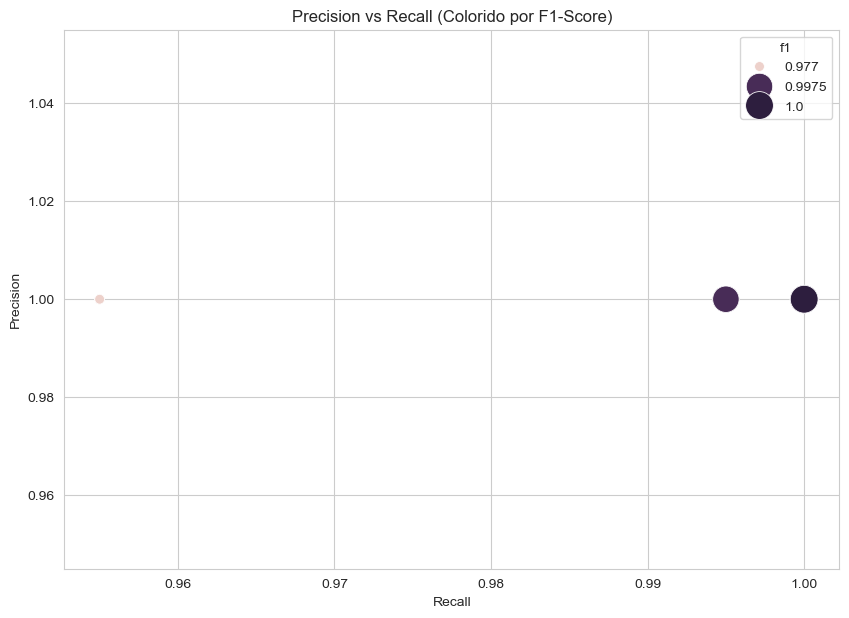

In [26]:
# Plot de dispersão de Precision vs Recall, colorindo por F1-Score
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(data=results_df, x='recall', y='precision', hue='f1', size='f1', sizes=(50, 400), legend='full')
plt.title('Precision vs Recall (Colorido por F1-Score)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

Portanto, agora temos os melhores parâmetros para maximização do F1 e com excelentes métricas, mantendo uma ótima perfomance

In [27]:
# Aplicação Final e Validação no Val_Split (20% - Unseen)
if best_params:
    # Aplicar os melhores parâmetros no full geo_blocked_df (para predições finais)
    final_matches_df = apply_matching_rules(
        geo_blocked_df,
        best_params['name_sim_thresh'],
        best_params['addr_sim_thresh'],
        best_params['final_geo_dist_km'],
        best_params['flexible_name_sim_thresh'],
        best_params['flexible_geo_dist_thresh']
    )
    
    # Calcular métricas FINAIS no VAL_SPLIT (20% - simula unseen data)
    final_val_metrics = calculate_metrics_in_notebook(final_matches_df, val_split)
    
    # Para comparação: Recalcular no full train
    final_train_metrics = calculate_metrics_in_notebook(final_matches_df, train_truth_df)
    
    print("=== VALIDAÇÃO ===")
    print(f"F1 no FULL TRAIN (original): {final_train_metrics['f1']}")
    print(f"F1 no TRAIN_SPLIT (80%, tuning): {best_f1}")
    print(f"F1 no VAL_SPLIT (20%, unseen): {final_val_metrics['f1']}")
    print("\nDetalhes no Val_Split:")
    for k, v in final_val_metrics.items():
        print(f"  {k}: {v}")

=== VALIDAÇÃO ===
F1 no FULL TRAIN (original): 1.0
F1 no TRAIN_SPLIT (80%, tuning): 1.0
F1 no VAL_SPLIT (20%, unseen): 1.0

Detalhes no Val_Split:
  true_positives: 50
  false_positives: 0
  false_negatives: 0
  precision: 1.0
  recall: 1.0
  f1: 1.0


In [28]:
# Salvar output
output_for_submission = final_matches_df[['id_A', 'id_B', 'predicted_match']]
output_csv_path = 'output.csv'
output_for_submission.to_csv(output_csv_path, index=False)
print(f"\nOutput salvo: {output_csv_path}")


Output salvo: output.csv
